In [116]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

In [11]:
mpg = sns.load_dataset('mpg')
mpg

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger


In [121]:
mpg["date_range"] = np.where(mpg["model_year"] <= 74, "70-74",
                     np.where(mpg["model_year"] <= 79, "75-79", "80-82"))
mpg

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name,make,year_group,year_4,date_range
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu,chevrolet,68,68,70-74
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320,other,68,68,70-74
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite,other,68,68,70-74
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst,other,68,68,70-74
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino,ford,68,68,70-74
...,...,...,...,...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl,ford,80,80,80-82
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup,vw,80,80,80-82
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage,dodge,80,80,80-82
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger,ford,80,80,80-82


# Create a visual showing the relationship between horsepower and fuel economy.

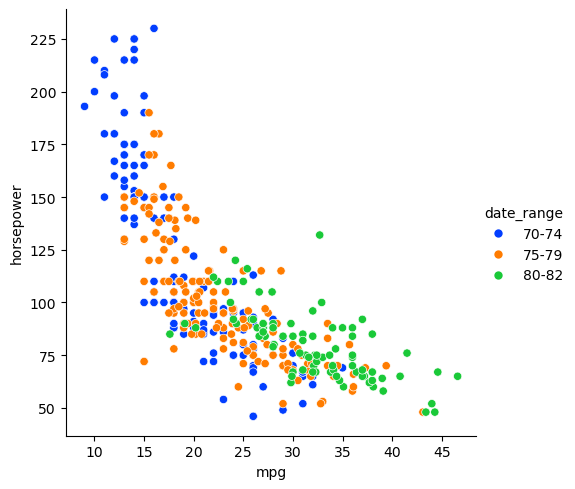

In [122]:
sns.relplot(data=mpg, x='mpg', y='horsepower', hue='date_range')

### My observation of this scatterplot is there is a correlation between mpg and horsepower. The higher the mpg, the lower the horsepower of the vehicle. The vehicles that had high horsepower had lower mpg. This visual also shows the priority of vehicle design change over the course of about a decade. Cars with a model year of 70 typically had high horsepower and low mpg. Most vehicles with model year of 82 show a higher priority in mpg while being willing to have a lower horsepower.

# Create a table summarizing fuel economy by country of origin

In [32]:
mpg_by_country = mpg.groupby("origin")['mpg'].mean().reset_index().sort_values(by="mpg", ascending=False).round(2)
mpg_by_country

,origin,mpg
1,japan,30.45
0,europe,27.89
2,usa,20.08


### The data shows that cars made in Japan have the highest fuel economy on average, with the USA having a significantly lower average.

# Create a visual showing how fuel economy has changed over time

Text(0.5, 1.0, 'Fuel Economy over time')

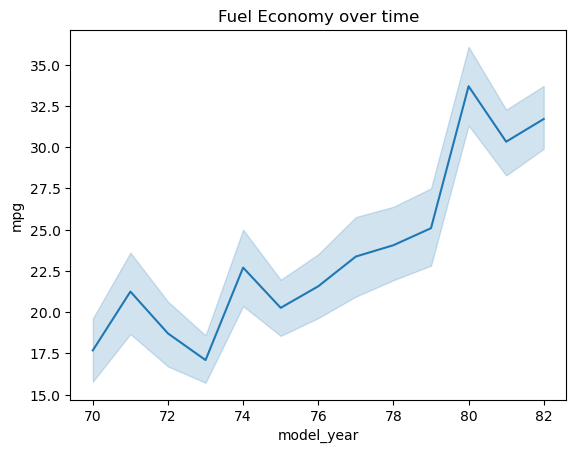

In [35]:
sns.lineplot(data=mpg, y="mpg", x="model_year")
plt.title('Fuel Economy over time')

### The short answer is that over time fuel economy improved. However, we can see that some years had significant increases in fuel economy compared to the year prior and the year following; Years like '71, '74, & '80. We also see years like '73, '75 & '81 that had drops in the average. Overall this shows that as time progressed, fuel economy became more important shown by improvements.

# Create two other visuals or tables related to fuel economy.

In [51]:
import numpy as np
mpg['make'] = np.where(mpg.name.str.contains("ford"), 'ford',
                       np.where(mpg.name.str.contains("toyota"), 'toyota',
                                np.where(mpg.name.str.contains("chevrolet"), 'chevrolet',
                                         np.where(mpg.name.str.contains("honda"), 'honda',
                                                  np.where(mpg.name.str.contains("volkswagen"), 'vw',
                                                           np.where(mpg.name.str.contains("vw"), 'vw',
                                                                    np.where(mpg.name.str.contains("dodge"), 'dodge', 'other')))))))

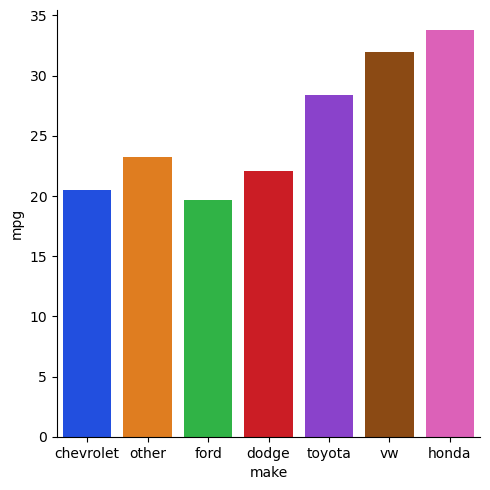

In [89]:
sns.catplot(data=mpg, x="make", y="mpg", kind='bar', hue="make", estimator='average', errorbar=None, legend=False)

### This visual shows 6 of the big car manufacturers and the average mpg of the vehicles they create. An other category has also been placed here to show an average of other car companies. This chart tells us that Honda, Volkswagen and Toyota prioritize fuel effeciency in their vehicles. Companies like Ford, Chevrolet and Dodge don't have as high of a priority on fuel economy compared to the average from the 'other' manufacturers.

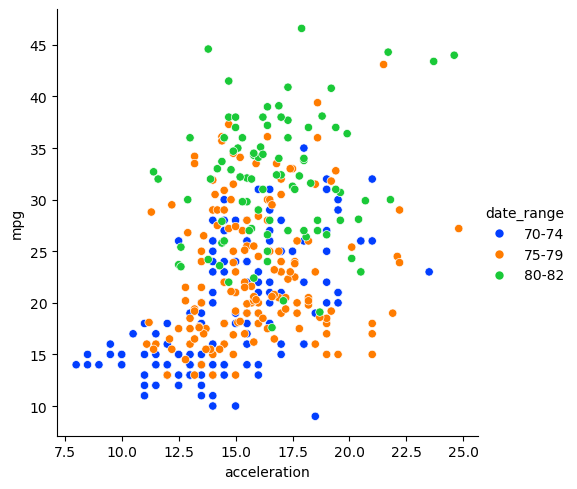

In [123]:
sns.relplot(data=mpg, x="acceleration", y="mpg", hue="date_range")


### This chart is made to show if there is a correlation between the acceleration of a vehicle and the mpg over the course of a decade. You can tell from this visual that most of the dots are in the 12.5-20.0 range for acceleration. The mpg of these vehicles however improve as time goes on. Acceleration does not improve dramatically, but the mpg that goes with the vehicle does. This tells us that later vehicles are able to have better fuel economy without having to compro